## Kenya E-commerce & Delivery Performance Analytics

### Business Problem 

The e-commerce company lacks a clear understanding of how geographic location, courier performance, and delivery characteristics affect operational performance and customer experience.

In [131]:
import pandas as pd
import matplotlib.pyplot as plt

In [132]:
data = pd.read_csv("messy_kenya_ecommerce_large.csv")


In [133]:
data.head()

,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating
0,KE-10001,CUST-5327,NaN,Mombasa,Fashion & Apparel,22674.0,NaN,Pickup Station,G4S,35kg,353,6.0,Cancelled,3.0
1,KE-10002,CUST-5414,2025-01-04,kiambu,Fashion & Apparel,11529.0,Cash on Delivery,Home Delivery,DHL,16.13,537,3.0,Delivered,5.0
2,KE-10003,CUST-5098,2025-12-27,Mombasa,Health & Wellness,3809.0,m-pesa,Pickup Station,DHL,9.42,223,2.0,Delayed,4.0
3,KE-10004,CUST-5138,2025-11-24,Kiambu,Health & Wellness,1551.0,Credit/Debit Card,Smart Locker,G4S,22.97,619,2.0,Delivered,NaN
4,KE-10005,CUST-5299,2025-08-08,Mombasa,Fashion & Apparel,3478.0,m-pesa,Boda Boda Last-Mile,Local Rider,2.32,629,NaN,Returned,1.0


In [134]:
data.tail()

,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating
995,KE-10996,CUST-5481,2025-12-24,Kiambu,Beauty,2322.0,M-Pesa,Boda Boda Last-Mile,Chui Lockers,15.04,254,3.0,Delivered,5.0
996,KE-10997,CUST-5481,2025-10-07,Nairobi,Health & Wellness,-17996,COD,Pickup Station,DHL,32.74,568,5.0,Delayed,2.0
997,KE-10998,CUST-5387,2025-11-30,Mombasa,Electronics,10571.0,m-pesa,Pickup Station,Chui Lockers,23.15,564,1.0,Returned,2.0
998,KE-10999,CUST-5037,2025-09-12,Mombasa,Health & Wellness,22233.0,Credit/Debit Card,Home Delivery,Local Rider,7.02,365,2.0,Delivered,3.0
999,KE-11000,CUST-5140,2025-08-18,Mombasa,Electronics,18015.0,M-Pesa,Home Delivery,DHL,29.31,228,5.0,Delivered,NaN


In [135]:
data.shape

(1000, 14)

In [136]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            1000 non-null   object 
 1   Customer_ID         1000 non-null   object 
 2   Order_Date          964 non-null    object 
 3   Customer_County     972 non-null    object 
 4   Product_Category    1000 non-null   object 
 5   Order_Value_KES     971 non-null    object 
 6   Payment_Method      966 non-null    object 
 7   Delivery_Method     1000 non-null   object 
 8   Courier_Partner     1000 non-null   object 
 9   Package_Weight_Kg   1000 non-null   object 
 10  Shipping_Fee_KES    1000 non-null   int64  
 11  Transit_Time_Days   952 non-null    float64
 12  Fulfillment_Status  1000 non-null   object 
 13  Customer_Rating     848 non-null    float64
dtypes: float64(2), int64(1), object(11)
memory usage: 109.5+ KB


In [137]:
data = data.map(lambda x: x.strip() if isinstance(x, str) else x)


In [138]:
data[data.duplicated(keep= False)]


,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating


In [139]:
data["Order_Date"] = pd.to_datetime(data["Order_Date"], dayfirst=True,errors='coerce')




In [140]:
data["Order_Date"].dtype


dtype('<M8[ns]')

In [141]:

data["Customer_County"].value_counts()



Customer_County
Mombasa           169
nairobi           101
kiambu             92
Machakos           85
Kajiado            82
Kiambu             78
Uasin Gishu        77
Nairobi County     76
Nairobi            76
Nakuru             71
Kisumu             65
Name: count, dtype: int64

In [142]:

data["Customer_County"] = data["Customer_County"].str.title()
data["Customer_County"] = data["Customer_County"].replace({'Nairobi County': 'Nairobi'})


In [143]:
data['Product_Category'].value_counts()

Product_Category
Electronics          161
Home & Living        157
Beauty               153
Fashion & Apparel    142
Health & Wellness    139
Groceries            126
FASHION              102
electrnics            20
Name: count, dtype: int64

In [144]:
data['Product_Category']=data['Product_Category'].str.title()
data['Product_Category']= data["Product_Category"].replace({'Electrnics':'Electronics'})


In [145]:
data['Product_Category'].value_counts()

Product_Category
Electronics          181
Home & Living        157
Beauty               153
Fashion & Apparel    142
Health & Wellness    139
Groceries            126
Fashion              102
Name: count, dtype: int64

In [146]:
data.drop(columns=['Product_category'], inplace=True)


KeyError: "['Product_category'] not found in axis"

In [147]:
data["Order_Value_KES"].dtype

dtype('O')

In [148]:
data['Order_Value_KES'].value_counts().head(20) #show the top most 20 unique values and their frequencies

Order_Value_KES
19795.0       3
KSh 18,091    2
23215.0       2
20715.0       2
22236.0       2
4193.0        2
20469.0       2
19870.0       2
9204.0        2
10795.0       2
5926.0        2
18577.0       2
17503.0       2
13304.0       2
3374.0        2
15973.0       2
19024.0       2
16919.0       2
21866.0       2
10346.0       2
Name: count, dtype: int64

In [149]:
data["Order_Value_KES"].str.contains('-',na=False).sum() ## negative value rows

19

In [150]:
# Remove 'KSh', commas, and whitespace, then convert to numeric float
data['Order_Value_KES'] = data['Order_Value_KES'].astype(str).str.replace(r'[KSh,\s]', '', regex=True)
data['Order_Value_KES'] = pd.to_numeric(data['Order_Value_KES'], errors='coerce')


In [151]:
data[data['Order_Value_KES']<0]

,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating
188,KE-10189,CUST-5307,NaT,Nairobi,Beauty,-20274.0,COD,Smart Locker,Sendy,24.45,643,4.0,Returned,5.0
192,KE-10193,CUST-5314,2025-02-12,Uasin Gishu,Health & Wellness,-21481.0,Credit/Debit Card,Home Delivery,Local Rider,17.92,779,1.0,Delivered,1.0
195,KE-10196,CUST-5195,NaT,Kajiado,Fashion,-12070.0,Cash on Delivery,Home Delivery,Chui Lockers,23.61,227,2.0,Cancelled,3.0
223,KE-10224,CUST-5269,NaT,Mombasa,Home & Living,-15735.0,COD,Smart Locker,Sendy,0.77,545,4.0,Delivered,4.0
411,KE-10412,CUST-5196,NaT,Mombasa,Electronics,-7637.0,Credit/Debit Card,Smart Locker,Wells Fargo,29.85,424,2.0,Delivered,1.0
528,KE-10529,CUST-5382,NaT,Machakos,Groceries,-22723.0,NaN,Boda Boda Last-Mile,DHL,4.63,763,6.0,Delivered,NaN
566,KE-10567,CUST-5457,NaT,Machakos,Groceries,-9526.0,M-Pesa,Home Delivery,DHL,20.99,598,1.0,Delivered,1.0
587,KE-10588,CUST-5292,NaT,Mombasa,Beauty,-9433.0,COD,Pickup Station,Chui Lockers,35kg,0,7.0,Delivered,1.0
626,KE-10627,CUST-5071,NaT,Kiambu,Home & Living,-17525.0,Credit/Debit Card,Pickup Station,DHL,8.01,492,3.0,Cancelled,4.0
696,KE-10697,CUST-5240,NaT,Uasin Gishu,Home & Living,-12135.0,Credit/Debit Card,Pickup Station,G4S,2.35,198,7.0,Delivered,5.0


In [152]:
# Convert all values to positive numbers
data['Order_Value_KES'] = data['Order_Value_KES'].abs()


In [153]:
data

,Order_ID,Customer_ID,Order_Date,Customer_County,Product_Category,Order_Value_KES,Payment_Method,Delivery_Method,Courier_Partner,Package_Weight_Kg,Shipping_Fee_KES,Transit_Time_Days,Fulfillment_Status,Customer_Rating
0,KE-10001,CUST-5327,NaT,Mombasa,Fashion & Apparel,22674.0,NaN,Pickup Station,G4S,35kg,353,6.0,Cancelled,3.0
1,KE-10002,CUST-5414,2025-04-01,Kiambu,Fashion & Apparel,11529.0,Cash on Delivery,Home Delivery,DHL,16.13,537,3.0,Delivered,5.0
2,KE-10003,CUST-5098,NaT,Mombasa,Health & Wellness,3809.0,m-pesa,Pickup Station,DHL,9.42,223,2.0,Delayed,4.0
3,KE-10004,CUST-5138,NaT,Kiambu,Health & Wellness,1551.0,Credit/Debit Card,Smart Locker,G4S,22.97,619,2.0,Delivered,NaN
4,KE-10005,CUST-5299,2025-08-08,Mombasa,Fashion & Apparel,3478.0,m-pesa,Boda Boda Last-Mile,Local Rider,2.32,629,NaN,Returned,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,KE-10996,CUST-5481,NaT,Kiambu,Beauty,2322.0,M-Pesa,Boda Boda Last-Mile,Chui Lockers,15.04,254,3.0,Delivered,5.0
996,KE-10997,CUST-5481,2025-07-10,Nairobi,Health & Wellness,17996.0,COD,Pickup Station,DHL,32.74,568,5.0,Delayed,2.0
997,KE-10998,CUST-5387,NaT,Mombasa,Electronics,10571.0,m-pesa,Pickup Station,Chui Lockers,23.15,564,1.0,Returned,2.0
998,KE-10999,CUST-5037,2025-12-09,Mombasa,Health & Wellness,22233.0,Credit/Debit Card,Home Delivery,Local Rider,7.02,365,2.0,Delivered,3.0


In [154]:
data["Payment_Method"].value_counts()

Payment_Method
Credit/Debit Card    199
M-Pesa               197
Cash on Delivery     196
COD                  188
m-pesa               186
Name: count, dtype: int64

In [155]:
data["Payment_Method"]= data["Payment_Method"].replace(
    {
        'm-pesa': 'M-Pesa',
        'COD': 'Cash on Delivery'
    }
)

In [156]:
data['Courier_Partner'].value_counts()

Courier_Partner
Wells Fargo     178
G4S             173
Chui Lockers    173
DHL             165
Local Rider     163
Sendy           148
Name: count, dtype: int64

In [157]:
data["Shipping_Fee_KES"].value_counts().head(20)

Shipping_Fee_KES
0      54
564     6
646     5
549     5
214     5
624     5
715     5
471     5
228     5
783     5
757     4
714     4
640     4
342     4
666     4
515     4
745     4
546     4
532     4
637     4
Name: count, dtype: int64

In [158]:
data['Transit_Time_Days'].dtype


dtype('float64')

In [159]:
data['Transit_Time_Days'].describe()

count    952.000000
mean      16.410714
std      111.096137
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max      999.000000
Name: Transit_Time_Days, dtype: float64

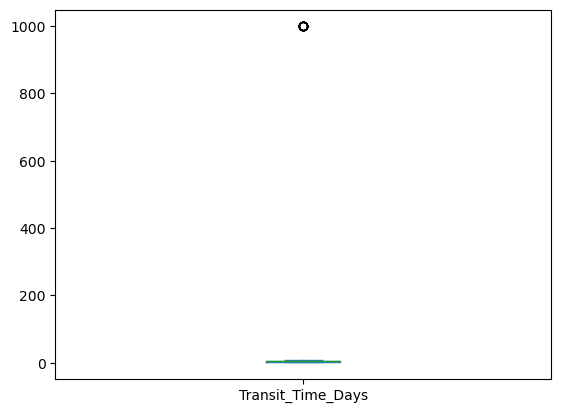

In [160]:
data['Transit_Time_Days'].plot(kind='box')
plt.show()

In [161]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data['Transit_Time_Days'].quantile(0.25)
Q3 = data['Transit_Time_Days'].quantile(0.75)

# Calculate the Interquartile Range
IQR = Q3 - Q1

# Define the upper boundary line
upper_boundary = Q3 + (1.5 * IQR)

print(f"The middle 50% of deliveries take between {Q1} and {Q3} days.")
print(f"Any delivery taking more than {upper_boundary} days is mathematically an outlier.")

# Filter the dataset to keep only normal, valid delivery times
data = data[data['Transit_Time_Days'] <= upper_boundary]


The middle 50% of deliveries take between 2.0 and 6.0 days.
Any delivery taking more than 12.0 days is mathematically an outlier.


In [162]:
data['Transit_Time_Days'].describe()

count    940.000000
mean       3.867021
std        2.035986
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max        7.000000
Name: Transit_Time_Days, dtype: float64

In [163]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 940 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Order_ID            940 non-null    object        
 1   Customer_ID         940 non-null    object        
 2   Order_Date          346 non-null    datetime64[ns]
 3   Customer_County     915 non-null    object        
 4   Product_Category    940 non-null    object        
 5   Order_Value_KES     911 non-null    float64       
 6   Payment_Method      908 non-null    object        
 7   Delivery_Method     940 non-null    object        
 8   Courier_Partner     940 non-null    object        
 9   Package_Weight_Kg   940 non-null    object        
 10  Shipping_Fee_KES    940 non-null    int64         
 11  Transit_Time_Days   940 non-null    float64       
 12  Fulfillment_Status  940 non-null    object        
 13  Customer_Rating     795 non-null    float64       
dtyp

In [164]:
data['Package_Weight_Kg'].value_counts().head(20)

Package_Weight_Kg
35kg     28
26.49     4
16.62     3
12.15     3
33.24     3
3.01      3
5.08      3
25.55     3
10.54     3
16.71     3
3.54      3
27.6      3
29.62     3
12.63     3
1.79      3
19.92     3
34.34     3
15.15     2
27.29     2
18.82     2
Name: count, dtype: int64

In [165]:
data['Package_Weight_Kg'] = (
    data['Package_Weight_Kg']
    .astype(str)
    .str.replace(r'(?i)\s*kg|\s*k', '', regex=True)
    .str.replace(',', '', regex=False)
    .str.strip()
)

data['Package_Weight_Kg'] = pd.to_numeric(
    data['Package_Weight_Kg'], 
    errors='coerce'
)

C:\Users\Ireneirungu\AppData\Local\Temp\ipykernel_34504\2187799942.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Package_Weight_Kg'] = (
C:\Users\Ireneirungu\AppData\Local\Temp\ipykernel_34504\2187799942.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Package_Weight_Kg'] = pd.to_numeric(


### Business Questions

Q1- Geographic Performance
How does e-commerce performance vary across Kenyan counties in terms of order volume, revenue, and delivery time?

Q2 — Courier performance

Which courier partners and delivery methods provide the best balance of delivery speed, fulfillment performance, and customer satisfaction?

Q3 — Delivery economics

How do package weight, shipping fees, and delivery time relate to each other?

Q4 — Customer experience

To what extent is delivery performance associated with customer satisfaction?

In [170]:
data.groupby('Customer_County')['Order_Value_KES'].sum()

Customer_County
Kajiado         947252.0
Kiambu         1827837.0
Kisumu          821921.0
Machakos        983651.0
Mombasa        2007711.0
Nairobi        3011530.0
Nakuru          867557.0
Uasin Gishu     887153.0
Name: Order_Value_KES, dtype: float64

In [168]:
data.groupby('Customer_County')['Order_Value_KES'].mean()

Customer_County
Kajiado        12463.842105
Kiambu         11946.647059
Kisumu         13256.790323
Machakos       12610.910256
Mombasa        13122.294118
Nairobi        13093.608696
Nakuru         13770.746032
Uasin Gishu    12321.569444
Name: Order_Value_KES, dtype: float64